# Perceptron Lab

This is the scaffold notebook for the perceptron lab and each lab will have a similar scaffold.  Make your own copy of this notebook and then you can fill in the tasks.  **You will fill in code boxes and test boxes with discussion for most tasks** and particularly discussion of results, graphs, etc. Good writing, grammar, punctuation, etc. are important and points will be taken off if these things are lacking. 

<b><u>In most cases just reporting results without discussion will not receive full credit.</u></b> Thus, your discussion should also include sentences like the following: This is because…  Note that the …  I was surprised to observe… I am not sure why …, but my hypothesis is that …

Start by looking over the scikit-learn [user guide](https://scikit-learn.org/stable/user_guide.html) and carefully reading over the [perceptron documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html).

In [105]:
# imports
import numpy as np
import pandas as pd
from scipy.io import arff

## 1. Debug and Evaluation

For most labs we will give you some data and expected results so that you can verify that you are doing things right and getting appropriate results.  We will then have you run on some other data with the exact same hyperparameters so we can see if your results are correct. 

### 1.1 Debug 
Download this [data set](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/linsep2nonorigin.arff) into your local directory and name it debug.arff.  To download rather than view, right-click the link and save as.  To allow consistent results run the Perceptron using the following hyperparameters:
- Learning rate = .1
- Do NOT shuffle the data after every epoch like you would normally do
- Learn for a maximum of 10 epochs
- Start all weights at 0 (which is the default for this scikit-learn implementation)  

Your results should be:
Accuracy = [.875]\
Final Weights = [[-0.23  0.18]]\
[-0.1] - This last weight is the bias weight, which they call the intercept.

To help you with this first task, following is one detailed variation that would do this for you. You may use your own variation.  Note that commonly used variable names in the community are clf (classifier), X (array of input features), y (vector of output labels).

In [106]:
from sklearn.linear_model import Perceptron

Data_Set = arff.loadarff("debug.arff")
Data_Set_df = pd.DataFrame(Data_Set[0])
Data_Set_np = Data_Set_df.to_numpy()
Data_Set_np = Data_Set_np.astype(float)
X = Data_Set_np[:, :-1]
y = Data_Set_np[:, -1]
print(X)
print(y)

clf = Perceptron(shuffle=False, verbose=0, eta0=0.1, max_iter=10)
clf.fit(X, y)
print(clf.coef_)
print(clf.intercept_)
print(clf.score(X, y))

[[-0.4  0.3]
 [-0.3  0.8]
 [-0.2  0.3]
 [-0.1  0.9]
 [-0.1  0.1]
 [ 0.  -0.2]
 [ 0.1  0.2]
 [ 0.2 -0.2]]
[1. 1. 1. 1. 0. 0. 0. 0.]
[[-0.23  0.18]]
[-0.1]
0.875


/home/hansil/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Notes:
* If you increase (or just remove) max_iter your perceptron will converge to 100% in one more epoch.  Try it!
* verbose (integer) specifies how much info you get after each epoch.  It does not change results.  Try it with 0.
    * Norm is a measure of the total weight magnitudes in the current model.
    * NNZs is the number of non-zero weights there currently are (not including the bias).
    * clf.intercept_ is the value of the bias weight, NOT the actual y-intercept of the decision surface, though it will affect that.
    * T is the total number of weight updates so far.  In this case all the weights were updated each epoch.
    * Avg. loss is another measure of error.  More on that later.
    * The activation function outputs 1 if net > 0, else 0.

### 1.2 Evaluation

Now train a perceptron model  on the [banknote authentication dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/data_banknote_authentication.arff) and report the final accuracy, weights, and bias. Use the exact same hyperparameters as the debug dataset. The most common reason for results not matching ours is not exactly using the same hyperparameters (e.g. initial weights, training exactly 10 epochs, no shuffling, etc.) Hint: Throughout these labs for the numerous cases where you are doing the same task, but with different data (e.g. debug, eval), you could create a function where you just pass the data set name, so as not to recreate the code multiple times.

In [107]:
# Load evaluation data
Data_Set_Bank = arff.loadarff("data_banknote_authentication.arff")
Data_Set_Bank_df = pd.DataFrame(Data_Set_Bank[0])
Data_Set_Bank_np = Data_Set_Bank_df.to_numpy()
Data_Set_Bank_np = Data_Set_Bank_np.astype(float)
X = Data_Set_Bank_np[:, :-1]
y = Data_Set_Bank_np[:, -1]
print(X)
print(y)

# Train on the evaluation data
clf = Perceptron(shuffle=False, verbose=0, eta0=0.1, max_iter=10)
clf.fit(X, y)

# print your accuracy and weights. Do not enter these values by hand.
print(clf.coef_)
print(clf.intercept_)
print(clf.score(X, y))

[[  3.6216    8.6661   -2.8073   -0.44699]
 [  4.5459    8.1674   -2.4586   -1.4621 ]
 [  3.866    -2.6383    1.9242    0.10645]
 ...
 [ -3.7503  -13.4586   17.5932   -2.7771 ]
 [ -3.5637   -8.3827   12.393    -1.2823 ]
 [ -2.5419   -0.65804   2.6842    1.1952 ]]
[0. 0. 0. ... 1. 1. 1.]
[[-4.28857497 -2.390381   -3.0160324  -1.1686672 ]]
[5.2]
0.9766763848396501


#### Discussion
Open the box below and type in your discussion.  Note that after each exercise you will have a chance to discuss your effort and results. What was your final accuracy? What was your experience running on the banknote authentication dataset? 

*The final accuracy was `0.9766763848396501`. My experience was pretty straightforward. It is nice how scikit-learn has integrated this. It was interesting how we formatted and wrangled the data with pandas and numpy so that scikit-learn could process it as well, that's something I think I will forget easily.*

## 2. Classifying on linearly separable and non-linearly separable data

### 2.1 Create 2 datasets

- Both with 8 instances using 2 real valued inputs with 4 instances from each class. 
- One data set should be linearly separable and the other not.
- Show or print your datasets

In [108]:
# Create and show the 2 datasets.
# You could do it here in Python or create arff files in your local folder with a text editor.  Either way show your dataset.

print("======================\n  linearly separable  \n======================")
Data_Set_separable = arff.loadarff("linearly_separable.arff")
Data_Set_separable_df = pd.DataFrame(Data_Set_separable[0])
Data_Set_separable_np = Data_Set_separable_df.to_numpy()
Data_Set_separable_np = Data_Set_separable_np.astype(float)
X_separable = Data_Set_separable_np[:, :-1]
y_separable = Data_Set_separable_np[:, -1]
print(X_separable)
print(y_separable)

print("\n======================\nnon linearly separable\n======================")
Data_Set_nonseparable = arff.loadarff("non_linearly_separable.arff")
Data_Set_nonseparable_df = pd.DataFrame(Data_Set_nonseparable[0])
Data_Set_nonseparable_np = Data_Set_nonseparable_df.to_numpy()
Data_Set_nonseparable_np = Data_Set_nonseparable_np.astype(float)
X_nonseparable = Data_Set_nonseparable_np[:, :-1]
y_nonseparable = Data_Set_nonseparable_np[:, -1]
print(X_nonseparable)
print(y_nonseparable)

  linearly separable  
[[1. 2.]
 [2. 1.]
 [2. 3.]
 [3. 2.]
 [6. 7.]
 [7. 8.]
 [8. 8.]
 [7. 6.]]
[0. 0. 0. 0. 1. 1. 1. 1.]

non linearly separable
[[1. 1.]
 [2. 2.]
 [8. 8.]
 [9. 9.]
 [1. 8.]
 [2. 9.]
 [8. 1.]
 [9. 2.]]
[0. 0. 0. 0. 1. 1. 1. 1.]


### 2.2 Train on both sets using the scikit-learn perceptron model
- Train on each and print the results. Train until convergence (i.e. use the default max_iter by simply not specifying it).
- You may choose your other hyperparameters.

In [109]:
# Train and print results with separable

# Train on the evaluation data
clf_separable = Perceptron(shuffle=True, verbose=0, eta0=0.02)
clf_separable.fit(X_separable, y_separable)

# print your accuracy and weights. Do not enter these values by hand.
print(clf_separable.coef_)
print(clf_separable.intercept_)
print(clf_separable.score(X_separable, y_separable))

[[0.02 0.02]]
[-0.16]
1.0


In [110]:
# Train and print results with non-separable

# Train on the evaluation data
clf_nonseparable = Perceptron(shuffle=False, verbose=0, eta0=0.02)
clf_nonseparable.fit(X_nonseparable, y_nonseparable)

# print your accuracy and weights. Do not enter these values by hand.
print(clf_nonseparable.coef_)
print(clf_nonseparable.intercept_)
print(clf_nonseparable.score(X_nonseparable, y_nonseparable))

[[0.16 0.16]]
[-0.06]
0.5


#### Discussion
What is different about the two runs? What makes one dataset not linearly separable? What is the result of the training? What is the accuracy of the two models?

*the two runs have different accuracies. The one that is linearly separable can converge to 100% accuracy, but the one that is not has a limit as it converges to 0.5. That means that the classifier is not able to separate the data in the non-separable set, resulting in the accuracy not converging to 1.*

### 2.3 Graph the datasets and their corresponding decision line
 
 - Graph each dataset
 - Use your trained perceptrons above to determine each dataset's decision line
    - We discssed how to find the slope and intercept in class and the equation is in the Perceptron slides
 - For all graphs always label the axes!
 - Following are examples of what graphs could look like
 
![Linearly Separable Data](https://raw.githubusercontent.com/rmorain/CS472-1/master/images/perceptron/linearly_separable.png)

![Not Linearly Separable](https://raw.githubusercontent.com/rmorain/CS472-1/master/images/perceptron/not_linearly_separable.png)

[-0.9 -0.6 -0.3 -0.1  0.1  0.3  0.6  0.9]
[-0.9    0.6    0.3    0.1    0.456 -0.324  0.778 -0.76 ]


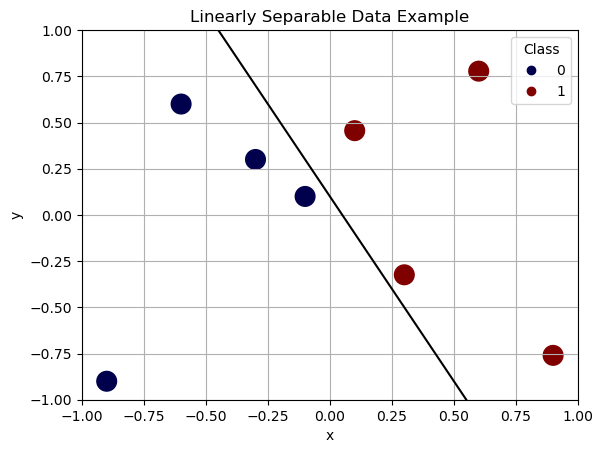

In [111]:
# Sample Graph code, You can use any graphing approach you want including this one.
# We encourage you to use matplotlib.
import matplotlib.pyplot as plt

# The data in this example is made up.  You will use your real data.
data = np.array(
    [
        [-0.9, -0.9],
        [-0.6, 0.6],
        [-0.3, 0.3],
        [-0.1, 0.1],
        [0.1, 0.456],
        [0.3, -0.324],
        [0.6, 0.778],
        [0.9, -0.76],
    ]
)
labels = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# Create a scatter plot of data
plt.xlim(-1, 1)
plt.ylim(-1, 1)
scatter = plt.scatter(data[:, 0], data[:, 1], c=labels, s=200, cmap="seismic")
print(data[:, 0])
print(data[:, 1])
legend = plt.legend(
    *scatter.legend_elements(num=1), title="Class", loc="upper right"
)  # Legend

# Plot the learned separator.  We just made up the slope and intercept for this example. You need to calculate
# the correct slope and intercept using your learned weights and bias.
xlist = np.linspace(
    -1.0, 1.0, 100
)  # create 100 evenly spaced points between -1 and 1 for the x axis
ylist = np.linspace(
    -1.0, 1.0, 100
)  # create 100 evenly spaced points between -1 and 1 for the y axis
slope = -2  # made up
intercept = 0.1  # made up
eq = slope * xlist + intercept
plt.plot(
    xlist,
    eq,
    "-k",
)
plt.title("Linearly Separable Data Example")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()  # add grid lines
plt.show()  # show the plot

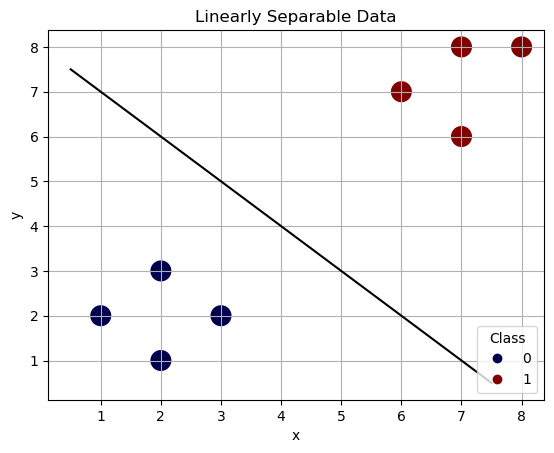

In [112]:
# Graph datasets and decision lines for both cases.
# Create a scatter plot of data
# plt.xlim(-1,1)
# plt.ylim(-1,1)
scatter = plt.scatter(
    X_separable[:, 0], X_separable[:, 1], c=labels, s=200, cmap="seismic"
)
legend = plt.legend(
    *scatter.legend_elements(num=1), title="Class", loc="lower right"
)  # Legend

# Plot the learned separator.  We just made up the slope and intercept for this example. You need to calculate
# the correct slope and intercept using your learned weights and bias.
xlist = np.linspace(
    0.5, 7.5, 100
)  # create 100 evenly spaced points between -1 and 1 for the x axis
ylist = np.linspace(
    0.5, 7.5, 100
)  # create 100 evenly spaced points between -1 and 1 for the y axis

w = clf_separable.coef_[0]
b = clf_separable.intercept_[0]
w1 = w[0]
w2 = w[1]

slope = -w1 / w2  # made up
intercept = -b / w2
eq = slope * xlist + intercept
plt.plot(
    xlist,
    eq,
    "-k",
)
plt.title("Linearly Separable Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()  # add grid lines
plt.show()  # show the plot

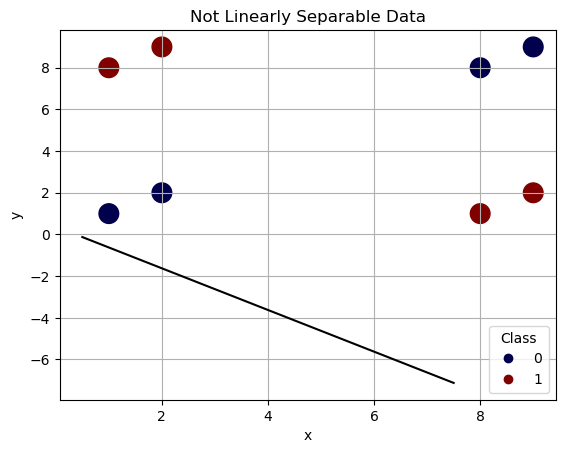

In [113]:
# Graph datasets and decision lines for both cases.
# Create a scatter plot of data
# plt.xlim(-1,1)
# plt.ylim(-1,1)
scatter = plt.scatter(
    X_nonseparable[:, 0], X_nonseparable[:, 1], c=labels, s=200, cmap="seismic"
)
legend = plt.legend(
    *scatter.legend_elements(num=1), title="Class", loc="lower right"
)  # Legend

# Plot the learned separator.  We just made up the slope and intercept for this example. You need to calculate
# the correct slope and intercept using your learned weights and bias.
xlist = np.linspace(
    0.5, 7.5, 100
)  # create 100 evenly spaced points between -1 and 1 for the x axis
ylist = np.linspace(
    0.5, 7.5, 100
)  # create 100 evenly spaced points between -1 and 1 for the y axis

w = clf_nonseparable.coef_[0]
b = clf_nonseparable.intercept_[0]
w1 = w[0]
w2 = w[1]

slope = -w1 / w2  # made up
intercept = -b / w2
eq = slope * xlist + intercept
plt.plot(
    xlist,
    eq,
    "-k",
)
plt.title("Not Linearly Separable Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()  # add grid lines
plt.show()  # show the plot

#### Discussion
What makes a dataset not linearly separable? How is the decision line determined? slope? y-intercept?

A dataset is not linearly separable if no linear decision boundary can classify all of its points correctly. For a two-feature perceptron, the boundary comes from w₁x₁ + w₂x₂ + b = 0, so its slope is −w₁/w₂ and its y-intercept is −b/w₂.

### 2.4 Discussion - In general, why will perceptrons not get perfect accuracy on non-linearly separable data

Because a perceptron learns a linear decision boundary, it cannot converge to perfect accuracy when the classes are not linearly separable. Although the plotted examples use two input features, a perceptron can use more features; the boundary is still linear in that higher-dimensional feature space.

## 3. Use the perceptron to learn this version of the [voting data set](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/voting-dataset.arff)

This particular task is an edited version of the standard voting set, where we have replaced all the “don’t know” values with the most common value for the particular attribute. Look at the [tutorial](https://github.com/cs472ta/CS472/blob/master/Tutorial.ipynb) from the Labs Content page to see examples of prepping the voting data set for sklearn.

### 3.1 Average final training and test set accuracy over multiple trials

- Learn the voting data five times with different random 70/30 Training/Test splits each time
- Use a learning rate of 1.  The other hyperparameters are up to you.
- Report the 5 trials and the average training and test accuracy and number of epochs to converge across the 5 trials in a table 
    - Below is an example of what a 2 trial table might look like

| Trial | Training Accuracy | Test accuracy | Number of epochs |
| --- | --- | --- | --- |
| 1 | .950 | .550 | 4 |
| 2 | .850 | .450 | 6 |
| Average | .900 | .500 | 5 | 

*- As a rough sanity check, typical Perceptron test accuracies for the voting data set are 90%-98%.*


In [114]:
voting_data = arff.loadarff("voting-dataset.arff")
voting_df = pd.DataFrame(voting_data[0])

voting_df.head()

,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa,Class
0,b'n',b'y',b'y',b'n',b'n',b'y',b'y',b'y',b'y',b'n',b'y',b'n',b'n',b'y',b'y',b'y',b'democrat'
1,b'n',b'n',b'y',b'y',b'n',b'y',b'y',b'y',b'y',b'y',b'n',b'y',b'n',b'y',b'n',b'y',b'republican'
2,b'n',b'y',b'y',b'n',b'y',b'y',b'n',b'n',b'n',b'n',b'y',b'n',b'y',b'y',b'n',b'n',b'democrat'
3,b'y',b'n',b'n',b'n',b'y',b'y',b'y',b'n',b'n',b'y',b'y',b'n',b'n',b'y',b'n',b'y',b'democrat'
4,b'y',b'y',b'y',b'y',b'y',b'y',b'n',b'n',b'y',b'n',b'y',b'n',b'y',b'y',b'n',b'n',b'democrat'


In [115]:
voting_np_data = np.array(voting_df)
voting_np_data

array([[b'n', b'y', b'y', ..., b'y', b'y', b'democrat'],
       [b'n', b'n', b'y', ..., b'n', b'y', b'republican'],
       [b'n', b'y', b'y', ..., b'n', b'n', b'democrat'],
       ...,
       [b'n', b'y', b'n', ..., b'n', b'y', b'republican'],
       [b'n', b'n', b'n', ..., b'n', b'y', b'republican'],
       [b'n', b'y', b'n', ..., b'n', b'n', b'republican']], dtype=object)

In [116]:
from sklearn.preprocessing import LabelEncoder

voting_label_encoded_df = voting_df.apply(LabelEncoder().fit_transform)

voting_label_encoded_df.head()

,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa,Class
0,0,1,1,0,0,1,1,1,1,0,1,0,0,1,1,1,0
1,0,0,1,1,0,1,1,1,1,1,0,1,0,1,0,1,1
2,0,1,1,0,1,1,0,0,0,0,1,0,1,1,0,0,0
3,1,0,0,0,1,1,1,0,0,1,1,0,0,1,0,1,0
4,1,1,1,1,1,1,0,0,1,0,1,0,1,1,0,0,0


In [117]:
voting_label_encoded_np = np.array(voting_label_encoded_df)
voting_label_encoded_np

array([[0, 1, 1, ..., 1, 1, 0],
       [0, 0, 1, ..., 0, 1, 1],
       [0, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 1, 1],
       [0, 0, 0, ..., 0, 1, 1],
       [0, 1, 0, ..., 0, 0, 1]])

In [118]:
X_voter = voting_label_encoded_np[:, :-1]
y_voter = voting_label_encoded_np[:, -1]

In [119]:
from sklearn.model_selection import train_test_split

In [120]:
# Run the perceptron 5 times on the voting data set with different splits and record the results.
# Hint: look up scikit-learn train_test_split
# Create the table using the tool of your choice

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X_voter, y_voter, test_size=0.3, random_state=1
)

voter_clf = Perceptron(shuffle=True, verbose=0, eta0=1, max_iter=16)
voter_clf.fit(X_train, y_train)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_train, y_train))
print(voter_clf.score(X_test, y_test))

[[  1.  -3.  -5.  19.   3.  -4.   4.   7.  -8.   4. -12.   2.   4.   4.
   -8.   0.]]
[-10.]
0.968944099378882
0.9640287769784173


In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X_voter, y_voter, test_size=0.3, random_state=2
)

voter_clf = Perceptron(shuffle=True, verbose=0, eta0=1, max_iter=10)
voter_clf.fit(X_train, y_train)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_train, y_train))
print(voter_clf.score(X_test, y_test))

[[ 0.  0. -8. 17.  3. -2.  4.  5. -8.  7. -9.  0.  2.  3. -3.  2.]]
[-9.]
0.9627329192546584
0.9280575539568345


In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X_voter, y_voter, test_size=0.3, random_state=3
)

voter_clf = Perceptron(shuffle=True, verbose=0, eta0=1, max_iter=10)
voter_clf.fit(X_train, y_train)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_train, y_train))
print(voter_clf.score(X_test, y_test))

[[-2. -2. -6. 16.  4. -2.  5.  6. -5.  2. -9.  2.  1.  1. -4.  0.]]
[-10.]
0.9627329192546584
0.9640287769784173


In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    X_voter, y_voter, test_size=0.3, random_state=4
)

voter_clf = Perceptron(shuffle=True, verbose=0, eta0=1, max_iter=11)
voter_clf.fit(X_train, y_train)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_train, y_train))
print(voter_clf.score(X_test, y_test))

[[ 3. -3. -7. 18.  4. -3.  6.  4. -6.  8. -7. -1. -1.  2. -6.  2.]]
[-7.]
0.9130434782608695
0.920863309352518


In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X_voter, y_voter, test_size=0.3, random_state=5
)

voter_clf = Perceptron(shuffle=True, verbose=0, eta0=1, max_iter=13)
voter_clf.fit(X_train, y_train)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_train, y_train))
print(voter_clf.score(X_test, y_test))

[[-2.  1. -8. 14.  4. -1.  7.  6. -4.  4. -8.  1. -1.  0. -7.  1.]]
[-8.]
0.9596273291925466
0.9568345323741008


| Trial | Training Accuracy | Test accuracy | Number of epochs |
| --- | --- | --- | --- |
| 1 | .969 | .964 | 16 |
| 2 | .963 | .928 | 10 |
| 3 | .963 | .964 | 10 |
| 4 | .913 | .921 | 11 |
| 5 | .960 | .957 | 13 |
| Average | .954 | .947 | 12 | 

### 3.2 Interpreting the Model
- Learn with the perceptron once on the full voting data set
- Look at the learned weights and bias and do your best to explain what the model has learned and how the individual input features affect the result. 
- Which specific features are most critical for the voting task, and which are least critical? 

In [126]:
# Learn once on the full voting data set.  If you Look at our tutorial at the beginning
voter_clf = Perceptron(shuffle=True, verbose=0, eta0=1, max_iter=10)
voter_clf.fit(X_voter, y_voter)
# print(voter_clf.coef_)
# print(voter_clf.intercept_)
# print(voter_clf.score(X_voter, y_voter))
print(voter_clf.coef_)
print(voter_clf.intercept_)

[[  0.  -3.  -8.  17.   4.  -2.   5.   6.  -7.   5. -10.  -1.  -1.   0.
   -4.   5.]]
[-9.]


### Discussion
How do the different features in the dataset effect prediction? How could you determine this? 

Looking at the weight magnitudes, the largest weight was assigned to index 3, `physician-fee-freeze`, making it the most influential feature in this fitted model. Indices 0 and 13 (`handicapped-infants` and `superfund-right-to-sue`) had weights of 0, so they did not affect this model's predictions.

### 3.3 Misclassification rate vs epochs 

Learn with the perceptron once on the full voting data set and graph the misclassification rate (number_misclassified  /  number_of_total_data_points) at each epoch until convergence (0th – final epoch).  Hints:
- For the 0th epoch (i.e. initial weights), assume the initial misclassification rate is 50% and let that be the first point on your graph. Since there are 2 output classes, random guessing would only get it right about 1/2 of the time. Missclassifcation rate is 1 - accuracy.
- Doing clf.fit with max_iter = 1, and warm_start=True will let you loop through epochs one at a time, allowing you to look at accuracy, etc. after each epoch.  But how do you know how many epochs to run until convergence?  One way is to just to first run it until convergence with random_state = c to see how many epochs it took (n_iter_).  Then run it again one epoch at a time n_iter_ times using the same random_state constant c (so that you get the exact same conditions).
- Below is a rough example of what this type of graph might look like (though this graph is for avg rate across multiple trials)

![Average Misclassification Rate](https://raw.githubusercontent.com/rmorain/CS472-1/master/images/perceptron/avg_misclassification_rate_vs_epochs.png)

In [127]:
# Learn once on the full voting data set, while gathering info after every epoch
# Then Graph it here.  Here is some sample graph code, but you can do it your own way, including using a bar graph, etc.


def plot_misclassification(misclassification_rate):
    """
        Plots the misclassification rate
    Args:
        misclassification_rate (array-like): A 1D array or list of missclassifcation rate at every epoch
    """
    plt.plot(np.arange(len(misclassification_rate)), misclassification_rate)
    plt.title("Misclassification Rate vs. Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Misclassification Rate")
    plt.show()

In [128]:
scores_list = [0.5]
i_clf = Perceptron(
    shuffle=True, verbose=0, eta0=1, max_iter=(20), random_state=1, warm_start=True
)
for i in range(20):
    i_clf.fit(X_voter, y_voter)
    score = i_clf.score(X_voter, y_voter)
    scores_list.append(1 - score)
    print(score)

0.8937093275488069
0.9587852494577006
0.9631236442516269
0.9414316702819957
0.9392624728850325
0.9674620390455532
0.9631236442516269
0.9587852494577006
0.9587852494577006
0.9674620390455532
0.9522776572668112
0.9718004338394793
0.9674620390455532
0.9631236442516269
0.9631236442516269
0.9609544468546638
0.9501084598698482
0.9761388286334056
0.9609544468546638
0.96529284164859


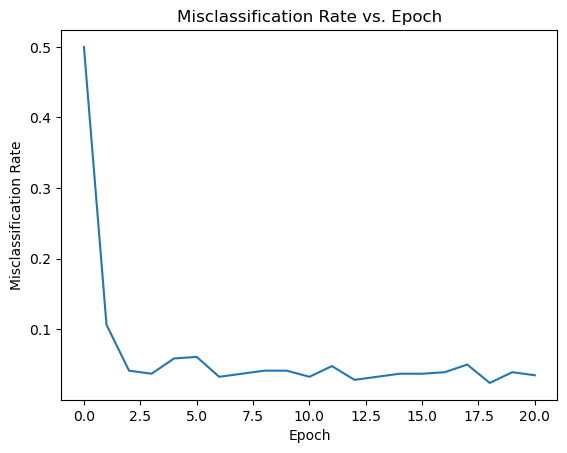

In [129]:
plot_misclassification(scores_list)

#### Discussion
Discuss the results in your graph. How quickly does the perceptron converge? Do you think this is typical? Are there any anomalies or anything you didn't expect?

The perceptron appears to settle after about 12 epochs. The spikes around epochs 4 and 5 may result from the shuffled updates and the relatively high learning rate of `1`; they are not necessarily errors. A smaller learning rate would likely produce smaller updates but could require more epochs to settle.

### 3.4 Hyperparameters
Read over all the Hyperparameters and their defaults in the scikit [perceptron documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html). With the voting data set, experiment briefly with EACH of the following 6 hyperparameters and discuss your findings.
- shuffle
- eta0 - learning rate
- verbose
- fit_intercept - whether to use a bias weight or not
- random state
- warm start

In [130]:
# Run the model with different hyperparameters
voter_clf = Perceptron(
    shuffle=True,
    eta0=0.5,
    verbose=False,
    fit_intercept=False,
    random_state=0,
    warm_start=False,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

print("\n")

voter_clf = Perceptron(
    shuffle=False,
    eta0=0.5,
    verbose=False,
    fit_intercept=False,
    random_state=0,
    warm_start=False,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

[[-2.  -3.  -4.   7.5  1.5 -2.5  1.   2.5 -3.   2.  -4.5  0.   0.5 -1.5
  -3.5  0. ]]
[0.]
0.93058568329718


[[ 0.  -2.  -2.5  6.5  1.  -1.   0.   1.5 -2.5  1.  -4.5  1.  -0.5 -0.5
  -1.5  2. ]]
[0.]
0.9522776572668112


In [131]:
# Run the model with different hyperparameters
voter_clf = Perceptron(
    shuffle=True,
    eta0=0.5,
    verbose=False,
    fit_intercept=False,
    random_state=0,
    warm_start=False,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

print("\n")

voter_clf = Perceptron(
    shuffle=True,
    eta0=0.1,
    verbose=False,
    fit_intercept=False,
    random_state=0,
    warm_start=False,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

[[-2.  -3.  -4.   7.5  1.5 -2.5  1.   2.5 -3.   2.  -4.5  0.   0.5 -1.5
  -3.5  0. ]]
[0.]
0.93058568329718


[[-2.00000000e-01 -3.00000000e-01 -9.00000000e-01  1.40000000e+00
   2.00000000e-01 -3.00000000e-01  2.00000000e-01  4.00000000e-01
  -6.00000000e-01  4.00000000e-01 -9.00000000e-01  2.77555756e-17
   1.00000000e-01 -3.00000000e-01 -3.00000000e-01  2.00000000e-01]]
[0.]
0.9631236442516269


In [132]:
# Run the model with different hyperparameters
voter_clf = Perceptron(
    shuffle=True,
    eta0=0.5,
    verbose=False,
    fit_intercept=False,
    random_state=0,
    warm_start=False,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

print("\n")

voter_clf = Perceptron(
    shuffle=True,
    eta0=0.5,
    verbose=True,
    fit_intercept=False,
    random_state=0,
    warm_start=False,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

[[-2.  -3.  -4.   7.5  1.5 -2.5  1.   2.5 -3.   2.  -4.5  0.   0.5 -1.5
  -3.5  0. ]]
[0.]
0.93058568329718


-- Epoch 1
Norm: 7.21, NNZs: 12, Bias: 0.000000, T: 461, Avg. loss: 0.150759
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 8.28, NNZs: 14, Bias: 0.000000, T: 922, Avg. loss: 0.144252
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 9.39, NNZs: 16, Bias: 0.000000, T: 1383, Avg. loss: 0.138829
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 10.15, NNZs: 12, Bias: 0.000000, T: 1844, Avg. loss: 0.140998
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 10.68, NNZs: 14, Bias: 0.000000, T: 2305, Avg. loss: 0.125813
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 11.57, NNZs: 15, Bias: 0.000000, T: 2766, Avg. loss: 0.099783
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 11.80, NNZs: 14, Bias: 0.000000, T: 3227, Avg. loss: 0.129067
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 12.29, NNZs: 15, Bias: 0.000000, T: 3688, Avg. loss: 0.137744
Total training tim

In [133]:
# Run the model with different hyperparameters
voter_clf = Perceptron(
    shuffle=True,
    eta0=0.5,
    verbose=False,
    fit_intercept=False,
    random_state=0,
    warm_start=False,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

print("\n")

voter_clf = Perceptron(
    shuffle=True,
    eta0=0.5,
    verbose=False,
    fit_intercept=True,
    random_state=0,
    warm_start=False,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

[[-2.  -3.  -4.   7.5  1.5 -2.5  1.   2.5 -3.   2.  -4.5  0.   0.5 -1.5
  -3.5  0. ]]
[0.]
0.93058568329718


[[ 0.  -1.5 -4.   8.5  2.  -1.   2.5  3.  -3.5  2.5 -5.  -0.5 -0.5  0.
  -2.   2.5]]
[-4.5]
0.9609544468546638


In [134]:
# Run the model with different hyperparameters
voter_clf = Perceptron(
    shuffle=True,
    eta0=0.5,
    verbose=False,
    fit_intercept=False,
    random_state=0,
    warm_start=False,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

print("\n")

voter_clf = Perceptron(
    shuffle=True,
    eta0=0.5,
    verbose=False,
    fit_intercept=False,
    random_state=1,
    warm_start=False,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

[[-2.  -3.  -4.   7.5  1.5 -2.5  1.   2.5 -3.   2.  -4.5  0.   0.5 -1.5
  -3.5  0. ]]
[0.]
0.93058568329718


[[-1.  -2.  -4.   7.   1.5 -2.   1.   2.5 -3.5  1.  -5.  -0.5 -1.  -1.
  -2.   0. ]]
[0.]
0.9154013015184381


In [135]:
# Run the model with different hyperparameters
voter_clf = Perceptron(
    shuffle=True,
    eta0=0.5,
    verbose=False,
    fit_intercept=False,
    random_state=0,
    warm_start=False,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

print("\n")

voter_clf = Perceptron(
    shuffle=True,
    eta0=0.5,
    verbose=False,
    fit_intercept=False,
    random_state=0,
    warm_start=True,
)
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))
voter_clf.fit(X_voter, y_voter)
print(voter_clf.coef_)
print(voter_clf.intercept_)
print(voter_clf.score(X_voter, y_voter))

[[-2.  -3.  -4.   7.5  1.5 -2.5  1.   2.5 -3.   2.  -4.5  0.   0.5 -1.5
  -3.5  0. ]]
[0.]
0.93058568329718


[[-2.  -3.  -4.   7.5  1.5 -2.5  1.   2.5 -3.   2.  -4.5  0.   0.5 -1.5
  -3.5  0. ]]
[0.]
0.93058568329718
[[-1.5 -2.5 -5.   8.   1.5 -2.   1.   2.5 -3.5  2.  -5.  -0.5  0.5 -1.5
  -3.5  0.5]]
[0.]
0.9392624728850325


#### Discussion
Discuss your findings from the experimentation with the hyperparameters.

Each hyperparameter affected the experiment in a different way. `verbose` changes only the amount of output, while `random_state` helps measure or control variation rather than directly improving the model. `warm_start` changes whether a later fit continues from the existing weights. The learning rate, shuffling, intercept, and stopping settings affect the learned weights and accuracy, so they are useful choices to tune.

## 4. Use the perceptron to learn one other data set of your choice.  
- The UC Irvine Data Repository is one great source, but you may get your data set from wherever you like, though it should be a real world task.
- Report your results

In [136]:
# Load and Train on your dataset and report results
from ucimlrepo import fetch_ucirepo

# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets
# G3 is the final grade
df = pd.concat([X, y["G3"]], axis=1)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (649, 31)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,4,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,2,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,6,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,0,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,0,13


In [137]:
# Create a binary target variable 'pass' (1 if G3 >= 10, else 0)
df["pass"] = (df["G3"] >= 10).astype(int)

# Separate our features (X) and our target (y)
X = df.drop("pass", axis=1)
y = df["pass"]

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,4,11,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,2,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,6,12,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,0,14,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,0,13,1


In [138]:
# Identify categorical features (those with 'object' dtype)
categorical_features = X.select_dtypes(include=["object"]).columns

# Apply one-hot encoding using pandas
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

X_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [140]:
clf = Perceptron(eta0=0.5, random_state=42, max_iter=1000)

clf.fit(X_train, y_train)

print(clf.coef_)
print(clf.intercept_)
print(clf.score(X_test, y_test))

[[-72.   -1.  -15.5 -11.5  -9.   -2.  -14.  -32.5  -9.5   2.   -6.   17.5
   -6.  153.5 -47.5   6.    5.   -1.  -13.5  -2.    2.    0.5   3.5   2.5
  -25.   -7.   -5.5 -12.    0.   21.  -31.    3.5   2.   -3.5 -11.    2.
   -6.5   6.5   2.   -2.5]]
[-19.]
0.823076923076923


In [141]:
scores_list = [0.5]
i_clf = Perceptron(
    shuffle=True, verbose=0, eta0=0.5, max_iter=(10000), random_state=1, warm_start=True
)
for i in range(20):
    i_clf.fit(X_train, y_train)
    score = i_clf.score(X_test, y_test)
    scores_list.append(1 - score)
    print(score)

0.9230769230769231
0.9
0.9
0.9
0.8692307692307693
0.9153846153846154
0.8692307692307693
0.9
0.9230769230769231
0.9
0.9153846153846154
0.9153846153846154
0.9153846153846154
0.9307692307692308
0.9076923076923077
0.9230769230769231
0.9230769230769231
0.9076923076923077
0.9307692307692308
0.9076923076923077


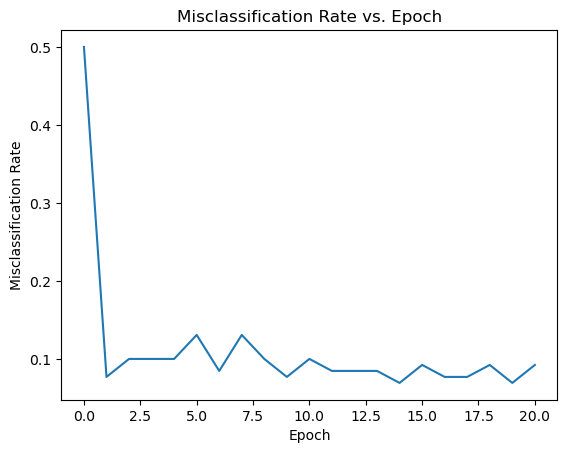

In [142]:
plot_misclassification(scores_list)

#### Discussion
Discuss how the perceptron did on the data set and why you think it performed as such.

The perceptron performed reasonably well at predicting whether students would pass or fail. This dataset was more difficult than the voting data: the test score was about 0.91 and varied across splits. Because the score was measured on a held-out test split, it is evidence against simply fitting the training examples, although one split cannot rule out overfitting. The features capture useful context, including study time, family information, and free time, but student performance remains nuanced.